# Posterior per-pixel denoising on MNIST

<div class="note"><span class="note-t">TL;DR</span>
<p>An offline UNet supplies clean-pixel probabilities, and Torx draws each output pixel through one <code>PNOT</code> gate. We show one genuine Torx draw separately from a thresholded 64-draw ensemble estimator. Offline FID metadata belongs only to the UNet artifacts.</p>
</div>

This tutorial uses the independent bit-flip corruption from discrete diffusion ([Austin et al. 2021](#ref-austin)) and its continuous-time Markov-chain form ([Campbell et al. 2022](#ref-campbell)) as the forward-process context. The executed method is narrower: a host UNet predicts each clean pixel's posterior probability, and Torx independently resamples the pixels from those probabilities.

A **forward process** corrupts a clean binary image by flipping pixels at random. The posterior denoiser estimates $\hat p_i = P(x_{0,i}=1 \mid x_t)$ from the corrupted image $x_t$.

We treat each pixel as a probabilistic bit, or **pbit**. One `PNOT` gate turns the current pixel into a Bernoulli draw with parameter $\hat p_i$.

The [UNet](https://arxiv.org/abs/1505.04597) checkpoint has 472,545 parameters and was trained offline. We load the committed weights and evaluation artifacts so the notebook stays fast. The repository does not include the training or FID evaluation script, so this page does not claim a reproducible training split or FID protocol.

By the end, you'll be able to:

- set up the forward bit-flip kernel and load the committed corrupted MNIST batch,
- turn the UNet's per-pixel clean probabilities into one `PNOT` logit per pbit,
- distinguish one stochastic Torx draw from a thresholded 64-draw ensemble estimator, and
- report the eight-image display-batch error separately from offline UNet artifact metrics.

## Setup

We import the local helpers, set the plotting style, and fix the random seed.

In [1]:
from pathlib import Path
import sys
import json

import equinox as eqx
import jax
import jax.numpy as jnp
import numpy as np



In [2]:
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [3]:
from _notebook_style import (
    apply_notebook_style,
    make_savefig,
)
from _notebook_paths import asset_dir, figure_dir
from _plots_schematics import draw_pcircuit
from _nb07_diffusion import (
    denoise_logits,
    frechet_distance,
    load_unet_params,
    pca_features,
)
from _plots_training import (
    plot_diffusion_loss,
    plot_fid_drop,
    plot_flip_probability,
    plot_reconstruction_grid,
)

from torx.psc import DiscretePCircuit, PNOT, BranchingSimulator


In [4]:
apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)
ASSET_DIR = asset_dir(ROOT, "nb07")
savefig = make_savefig(FIGURE_DIR)

SEED = 123

## Loading the checkpoint and evaluation grids

The committed artifacts under `assets/nb07/` hold the UNet parameters, saved training loss, evaluation grids, and sparse run metadata.

<details class="tx-disclosure"><summary>What runs where?</summary><ul><li>Torx: 784 <code>PNOT</code> gates and stochastic sampling.</li><li>Notebook code: probability-to-logit mapping, display-batch metrics, and PCA-space comparison.</li><li><code>examples/helpers/_nb07_diffusion.py</code>: host UNet inference and PCA/Fréchet calculations. <code>examples/helpers/_plots_training.py</code>: figures only.</li><li>Offline assets: <a href="https://github.com/extropic-ai/torx/blob/main/examples/assets/nb07/meta.json">metadata</a>, <a href="https://github.com/extropic-ai/torx/blob/main/examples/assets/nb07/eval_grids.npz">evaluation grids</a>, <a href="https://github.com/extropic-ai/torx/blob/main/examples/assets/nb07/loss_history.npy">loss history</a>, and <a href="https://github.com/extropic-ai/torx/blob/main/examples/assets/nb07/unet_mnist.msgpack">UNet weights</a>. Their generator is not committed.</li></ul></details>

The helper `load_unet_params` in `examples/helpers/_nb07_diffusion.py` rebuilds the UNet from the committed weights.

In [5]:
meta = json.loads((ASSET_DIR / "meta.json").read_text())
grids = np.load(ASSET_DIR / "eval_grids.npz")
loss_history = np.load(ASSET_DIR / "loss_history.npy")
# init the frozen UNet structure, then fill it from the committed msgpack
params = load_unet_params(ASSET_DIR / "unet_mnist.msgpack")



In [6]:
clean_all = grids["clean"].astype(np.int32)
noisy_all = grids["noisy"].astype(np.int32)
denoised_all = grids["denoised"].astype(np.int32)



In [7]:
# the checkpoint was scored at this single corruption level: a per-bit flip
# probability (the forward process flips each pixel independently with this prob)
forward_p = float(meta["p_flip"])



In [8]:
print(
    f"UNet: {meta['n_params']:,} params, {meta['n_steps']:,} steps, "
    f"final loss {meta['final_loss']:.3f}"
)
print(f"dataset: {meta['dataset']}")
print(f"eval grids: clean / noisy / denoised, each {clean_all.shape}")

UNet: 472,545 params, 30,000 steps, final loss 0.183
dataset: mnist_784 binarized@0.5, 28x28, 70k
eval grids: clean / noisy / denoised, each (64, 28, 28)


## Binarized pixels as pbits

We represent a binary image as one pbit per pixel.

The forward process is a continuous-time Markov chain, a random process that jumps between states at random times. It flips every bit independently using the uniform rate matrix, which sets a single flip rate shared by all pixels:

$$
Q = \begin{pmatrix} -1 & 1 \\ 1 & -1 \end{pmatrix}.
$$

Its time-$\sigma$ transition kernel is:

$$
e^{\sigma Q} = \begin{pmatrix}
\tfrac12 + \tfrac12 e^{-2\sigma} & \tfrac12 - \tfrac12 e^{-2\sigma} \\[3pt]
\tfrac12 - \tfrac12 e^{-2\sigma} & \tfrac12 + \tfrac12 e^{-2\sigma}
\end{pmatrix}.
$$

The off-diagonal entry $\tfrac12(1 - e^{-2\sigma})$ is the chance a bit has flipped by time $\sigma$, and the diagonal $\tfrac12(1 + e^{-2\sigma})$ is the chance it stayed put. At $\sigma = 0$ no bits have flipped, and as $\sigma \to \infty$ the flip probability rises toward $\tfrac12$, which is pure noise.

The committed `noisy` grids are clean MNIST images corrupted at the checkpoint's evaluation level: a per-bit flip probability `forward_p = 0.30`, meaning each pixel is flipped independently with probability 0.30. The next cell selects a display batch of eight images; the checks after it compare this rate against the observed bit error.

In [9]:
n_show = 8
clean = clean_all[:n_show]
noisy = noisy_all[:n_show]
denoised = denoised_all[:n_show]

height, width = clean.shape[1:]
num_bits = height * width

Before building circuits, check that the eight-image display batch is binary $28\times28$. All bit-error values below use only this display batch.

In [10]:
assert np.all((clean == 0) | (clean == 1))
assert np.all((noisy == 0) | (noisy == 1))
assert (height, width) == (28, 28)

print(f"image size: {height}x{width} = {num_bits} bits per image")
print(f"forward bit-flip rate: {forward_p}")
print(f"observed forward bit error: {float(np.mean(noisy != clean)):.3f}")

image size: 28x28 = 784 bits per image
forward bit-flip rate: 0.3
observed forward bit error: 0.301


The flip-probability curve shows how a single bit approaches the pure-noise limit as the noise time increases.

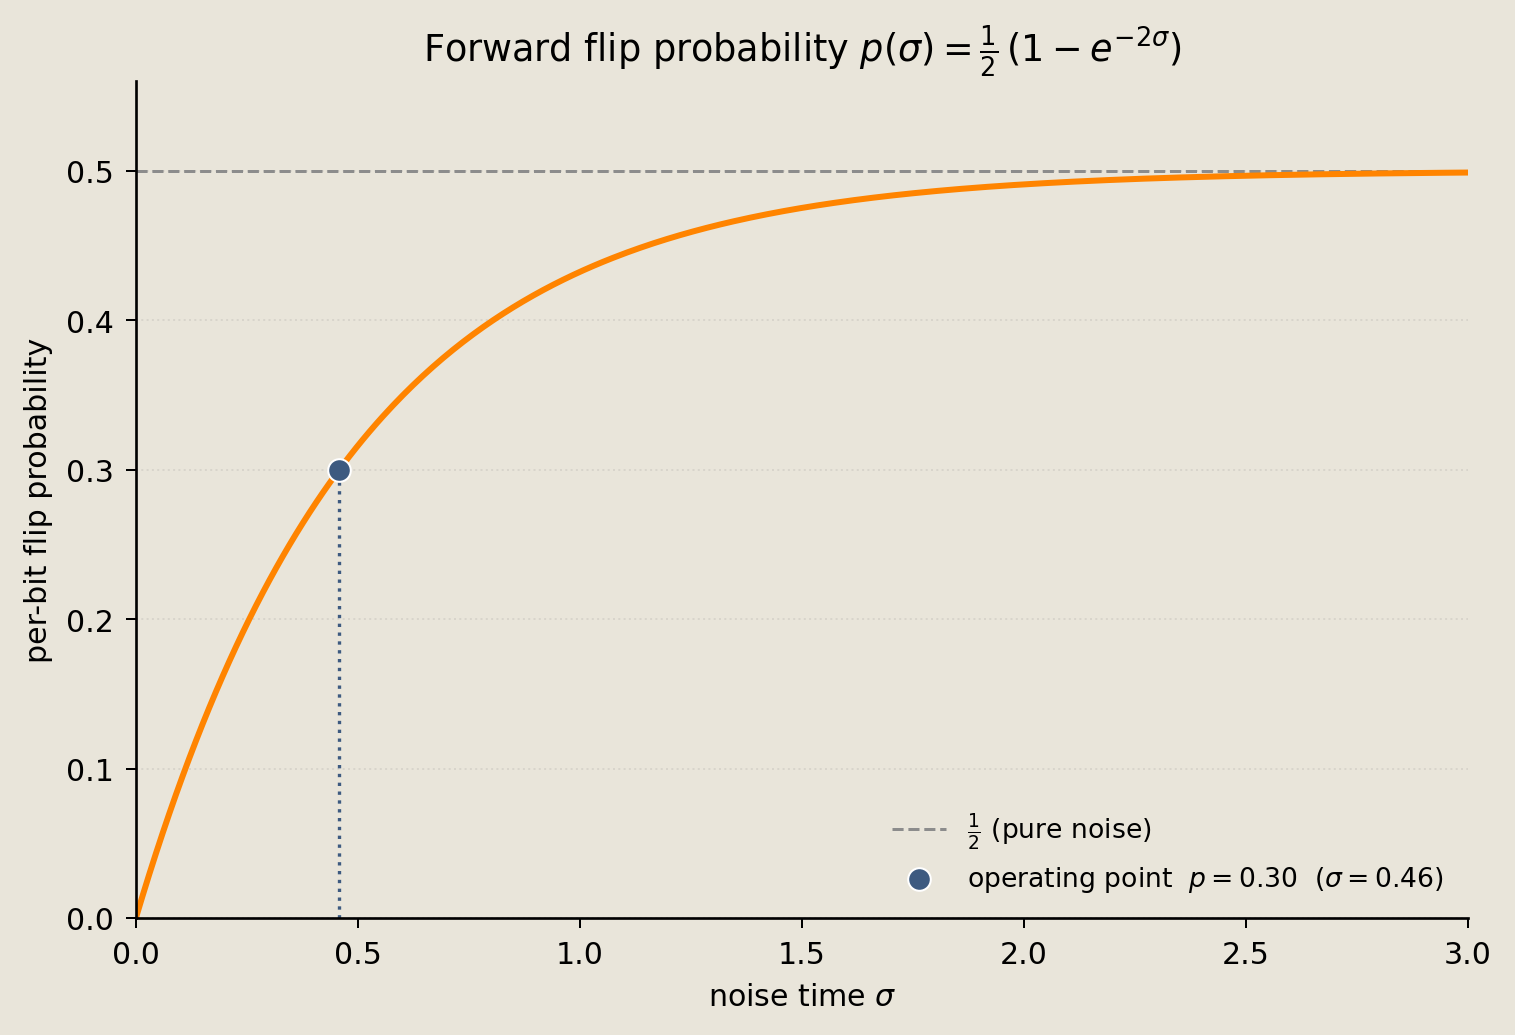

In [11]:
fig = plot_flip_probability(forward_p)
savefig(fig, "07_flip_probability")

The marked corruption level stays below the 0.5 pure-noise limit, so the corrupted images still carry enough signal for the reverse step.

## Posterior clean-bit probabilities

The host denoiser supplies the clean-pixel posterior probabilities that drive every gate.

It is a 472k-parameter UNet with two downsampling blocks, a bottleneck, and two upsampling blocks with skip connections. Each block uses two `GroupNorm`-normalized $3\times3$ convolutions. Its per-pixel sigmoid output $\hat p_i$ estimates $P(x_{0,i}=1 \mid x_t)$. The model definition and loader live in `examples/helpers/_nb07_diffusion.py`.

For current pixel $x_{t,i}$, set the `PNOT` flip probability to

$$
p^{(i)}_{\text{flip}} = \begin{cases} 1 - \hat p_i & x_{t,i} = 1 \\ \hat p_i & x_{t,i} = 0. \end{cases}
\qquad
\theta^{(i)} = \log \frac{p^{(i)}_{\text{flip}}}{1 - p^{(i)}_{\text{flip}}}.
$$

If the input is 0, the output is 1 exactly when `PNOT` flips. If the input is 1, the output stays 1 exactly when it does not flip. In both cases the output bit is therefore Bernoulli($\hat p_i$). This is posterior per-pixel denoising. It does not derive a joint time-transition kernel.

## Saved training loss

The artifact metadata records 30,000 offline gradient steps. We plot the committed training loss; the dashed line marks its final saved value.

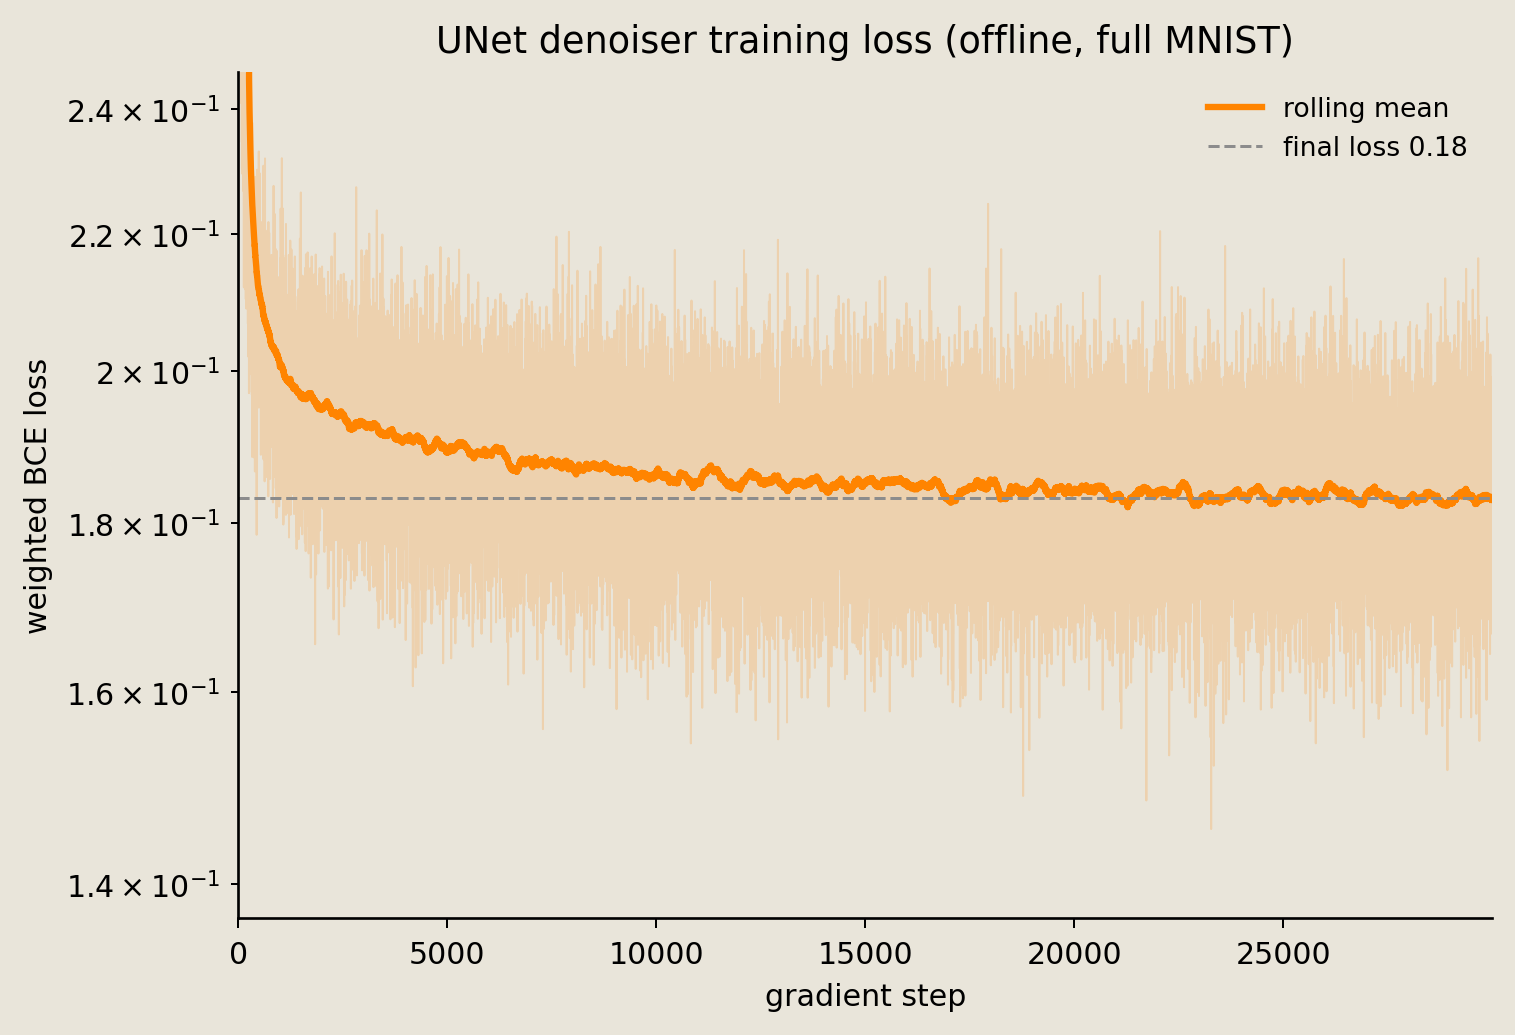

In [12]:
fig = plot_diffusion_loss(loss_history, reference_loss=meta["final_loss"])
savefig(fig, "07_diffusion_training_loss")

The saved training loss plateaus near the end. Without validation loss, a stopping rule, or the training script, this curve does not establish convergence or generalization.

## The posterior per-pixel circuit

One `PNOT` gate per pixel independently draws from the UNet's clean-bit marginal. The circuit does not include a time-step size or neighbor-conditioned joint transition.

The cell below wraps the helper's host UNet forward pass, `denoise_logits`, into a per-pixel clean-probability function.

In [13]:
def predict_clean_probability(batch, sigma):
    """Per-pixel clean probabilities from the offline-trained UNet."""
    # the denoiser reads both the noisy pixels and the current noise level
    logits = denoise_logits(params, batch.astype(np.float32), sigma)
    return np.asarray(jax.nn.sigmoid(logits))

This compact four-wire circuit shows the gate pattern used for posterior per-pixel draws.

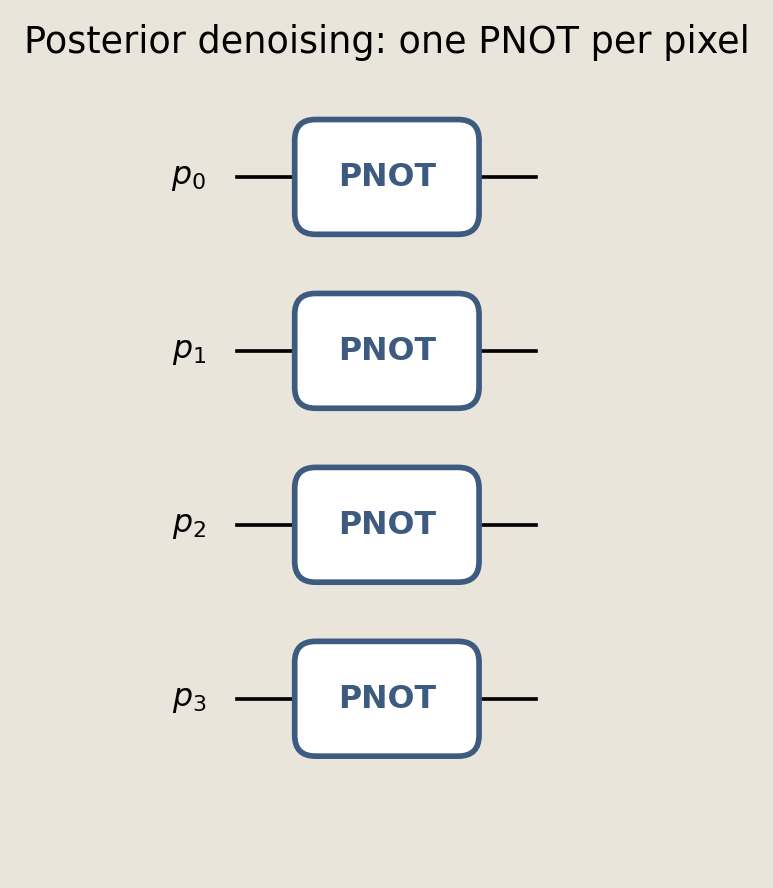

In [14]:
demo_specs = [
    ("PNOT", [0]),
    ("PNOT", [1]),
    ("PNOT", [2]),
    ("PNOT", [3]),
]
fig = draw_pcircuit(
    demo_specs,
    wire_labels=[r"$p_0$", r"$p_1$", r"$p_2$", r"$p_3$"],
    title="Posterior denoising: one PNOT per pixel",
)
savefig(fig, "07_posterior_circuit")

Each wire carries one independent posterior draw. The full circuit tiles this pattern across all 784 pixels.

Now assemble the 784-gate circuit template. `eqx.filter_jit` compiles the `vmap`-batched sampler once, and each image reuses it. The `num_draws` argument controls whether the returned mean represents one genuine draw or a Monte Carlo ensemble mean.

In [15]:
def torx_posterior_mean(batch, *, seed_offset=0, num_draws=1):
    """Return the mean of independent Torx posterior per-pixel draws."""
    x = batch.reshape(len(batch), -1).astype(np.int32)
    n_pixels = x.shape[1]
    sim = BranchingSimulator(num_samples=num_draws)

    gates = [PNOT(i) for i in range(n_pixels)]
    init_thetas = [jnp.zeros((1,)) for _ in gates]
    template = sim.build_circuit(DiscretePCircuit(gates), init_thetas)

    def sample_one(row, row_p, row_key):
        pnot_thetas = jnp.log(row_p / (1.0 - row_p))[:, None]
        compiled = eqx.tree_at(lambda c: c.thetas, template, pnot_thetas)
        return sim.sample(compiled, row, row_key).mean(axis=0)

    sample_batch = eqx.filter_jit(jax.vmap(sample_one))

    # Convert the committed per-bit corruption probability to CTMC time for
    # the host UNet conditioning channel: p = 0.5 * (1 - exp(-2 sigma)).
    sigma = -0.5 * float(np.log1p(-2 * forward_p))
    clean_prob = jnp.asarray(
        predict_clean_probability(x.reshape(len(batch), height, width), sigma)
    ).reshape(len(batch), -1)
    xj = jnp.asarray(x)
    p_flip = jnp.where(xj == 1, 1.0 - clean_prob, clean_prob)
    keys = jax.random.split(jax.random.key(SEED + seed_offset), len(x))
    mean = sample_batch(xj, p_flip, keys)
    return np.asarray(mean).reshape(batch.shape)

In [16]:
# With one draw, the returned mean is the genuine binary Torx sample itself.
torx_draw = torx_posterior_mean(noisy, seed_offset=10, num_draws=1).astype(np.int32)

# This separate run estimates each posterior marginal with 64 Torx draws.
torx_ensemble_mean = torx_posterior_mean(noisy, seed_offset=11, num_draws=64)

In [17]:
# Thresholding the 64-draw mean yields an ensemble posterior-mode estimator,
# not one stochastic sample.
torx_ensemble_binary = (torx_ensemble_mean >= 0.5).astype(np.int32)

In [18]:
forward_display_error = float(np.mean(noisy != clean))
unet_display_error = float(np.mean(denoised != clean))
torx_draw_display_error = float(np.mean(torx_draw != clean))
torx_ensemble_display_error = float(np.mean(torx_ensemble_binary != clean))

assert torx_ensemble_display_error < forward_display_error, (
    f"ensemble estimator must reduce display-batch error: "
    f"forward={forward_display_error:.3f}, ensemble={torx_ensemble_display_error:.3f}"
)

print("bit error on the 8-image display batch")
print(f"  forward corrupted:      {forward_display_error:.3f}")
print(f"  offline UNet threshold: {unet_display_error:.3f}")
print(f"  one Torx draw:          {torx_draw_display_error:.3f}")
print(f"  Torx 64-draw ensemble:  {torx_ensemble_display_error:.3f}")

bit error on the 8-image display batch
  forward corrupted:      0.301
  offline UNet threshold: 0.058
  one Torx draw:          0.127
  Torx 64-draw ensemble:  0.082


## Draw and ensemble grid

Each row shows the same eight $28\times28$ binary digits. The fourth row is one genuine stochastic Torx draw. The fifth row thresholds the mean of 64 separate Torx draws, so it is an ensemble posterior-mode estimator rather than one sample. Every printed bit-error value is scoped to these eight displayed images.

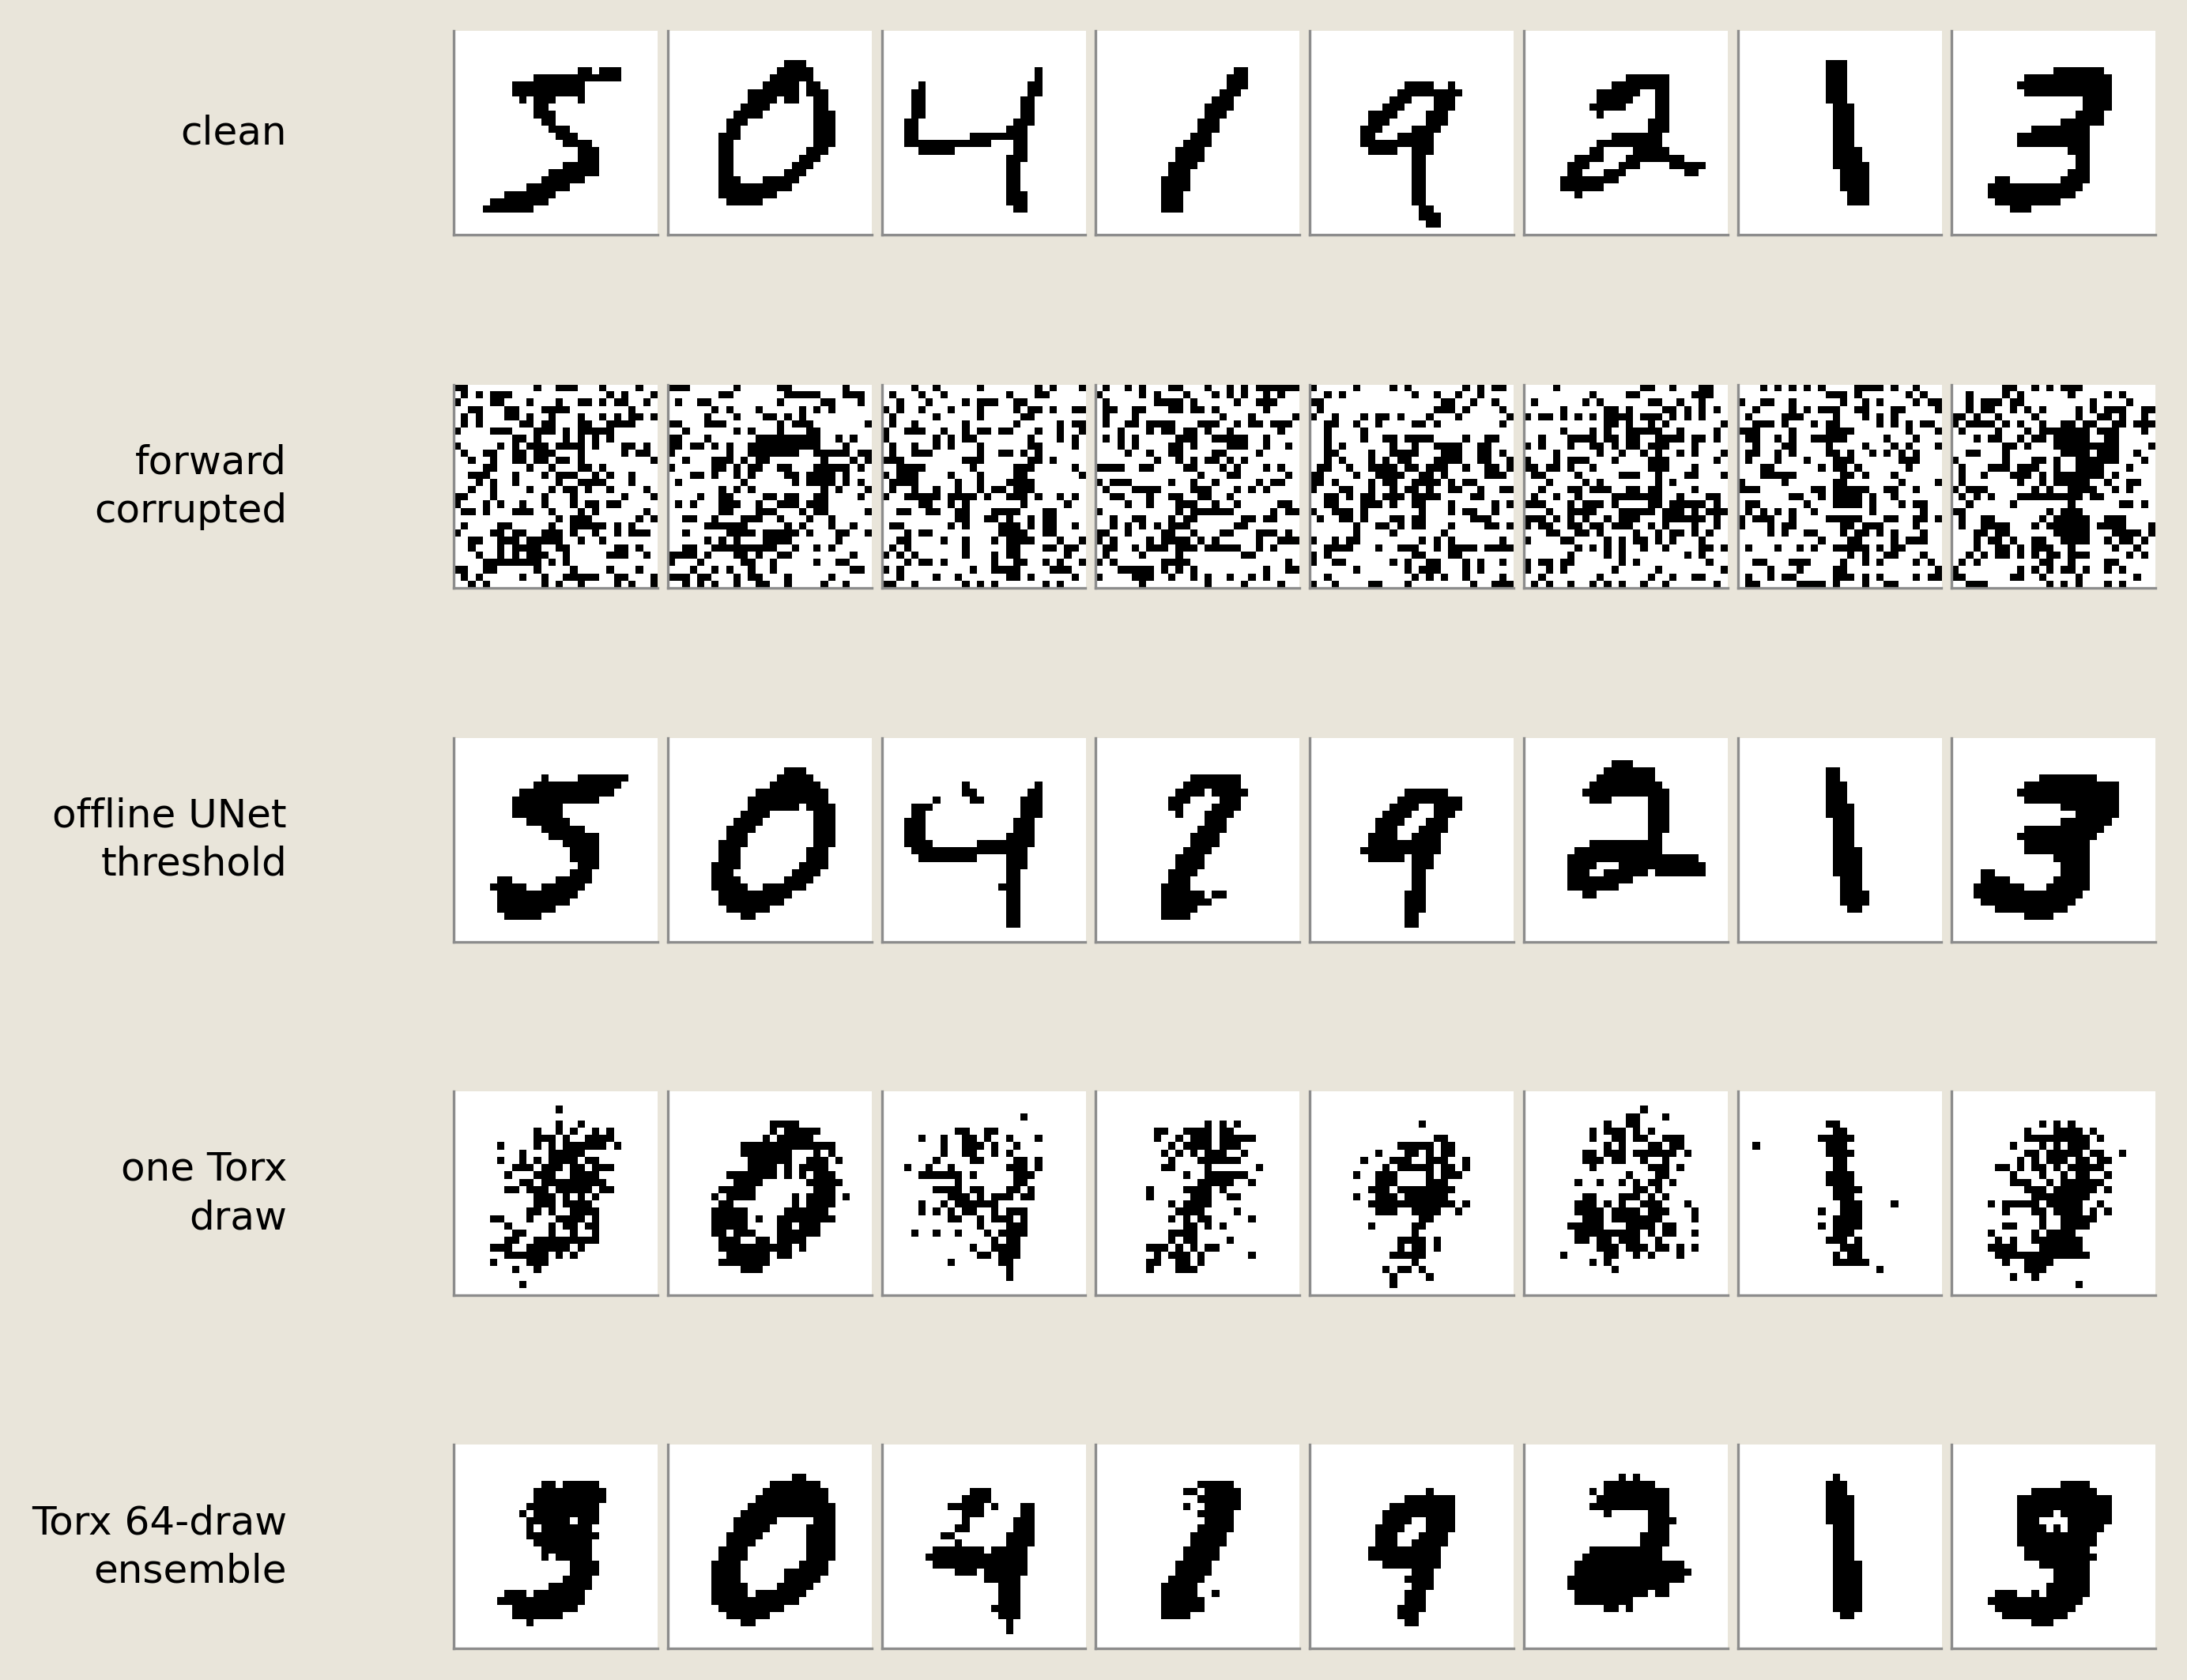

In [19]:
rows = [
    ("clean", clean),
    ("forward\ncorrupted", noisy),
    ("offline UNet\nthreshold", denoised),
    ("one Torx\ndraw", torx_draw),
    ("Torx 64-draw\nensemble", torx_ensemble_binary),
]
fig = plot_reconstruction_grid(rows)
savefig(fig, "07_discrete_diffusion_samples")

On this eight-image display batch, both Torx outputs reduce bit error. The single draw retains visible sampling variation, while the 64-draw estimator follows the UNet threshold more closely.

## Offline UNet artifact metric

[Fréchet inception distance](https://arxiv.org/abs/1706.08500) compares Gaussians fitted to Inception features from two image sets.

The committed metadata records 19.21 for corrupted images and 2.63 for offline UNet-denoised images. These values do not score either Torx output. The evaluation split, sample count, preprocessing, and FID implementation are not committed, so the figure reports checkpoint metadata rather than a notebook-reproduced result.

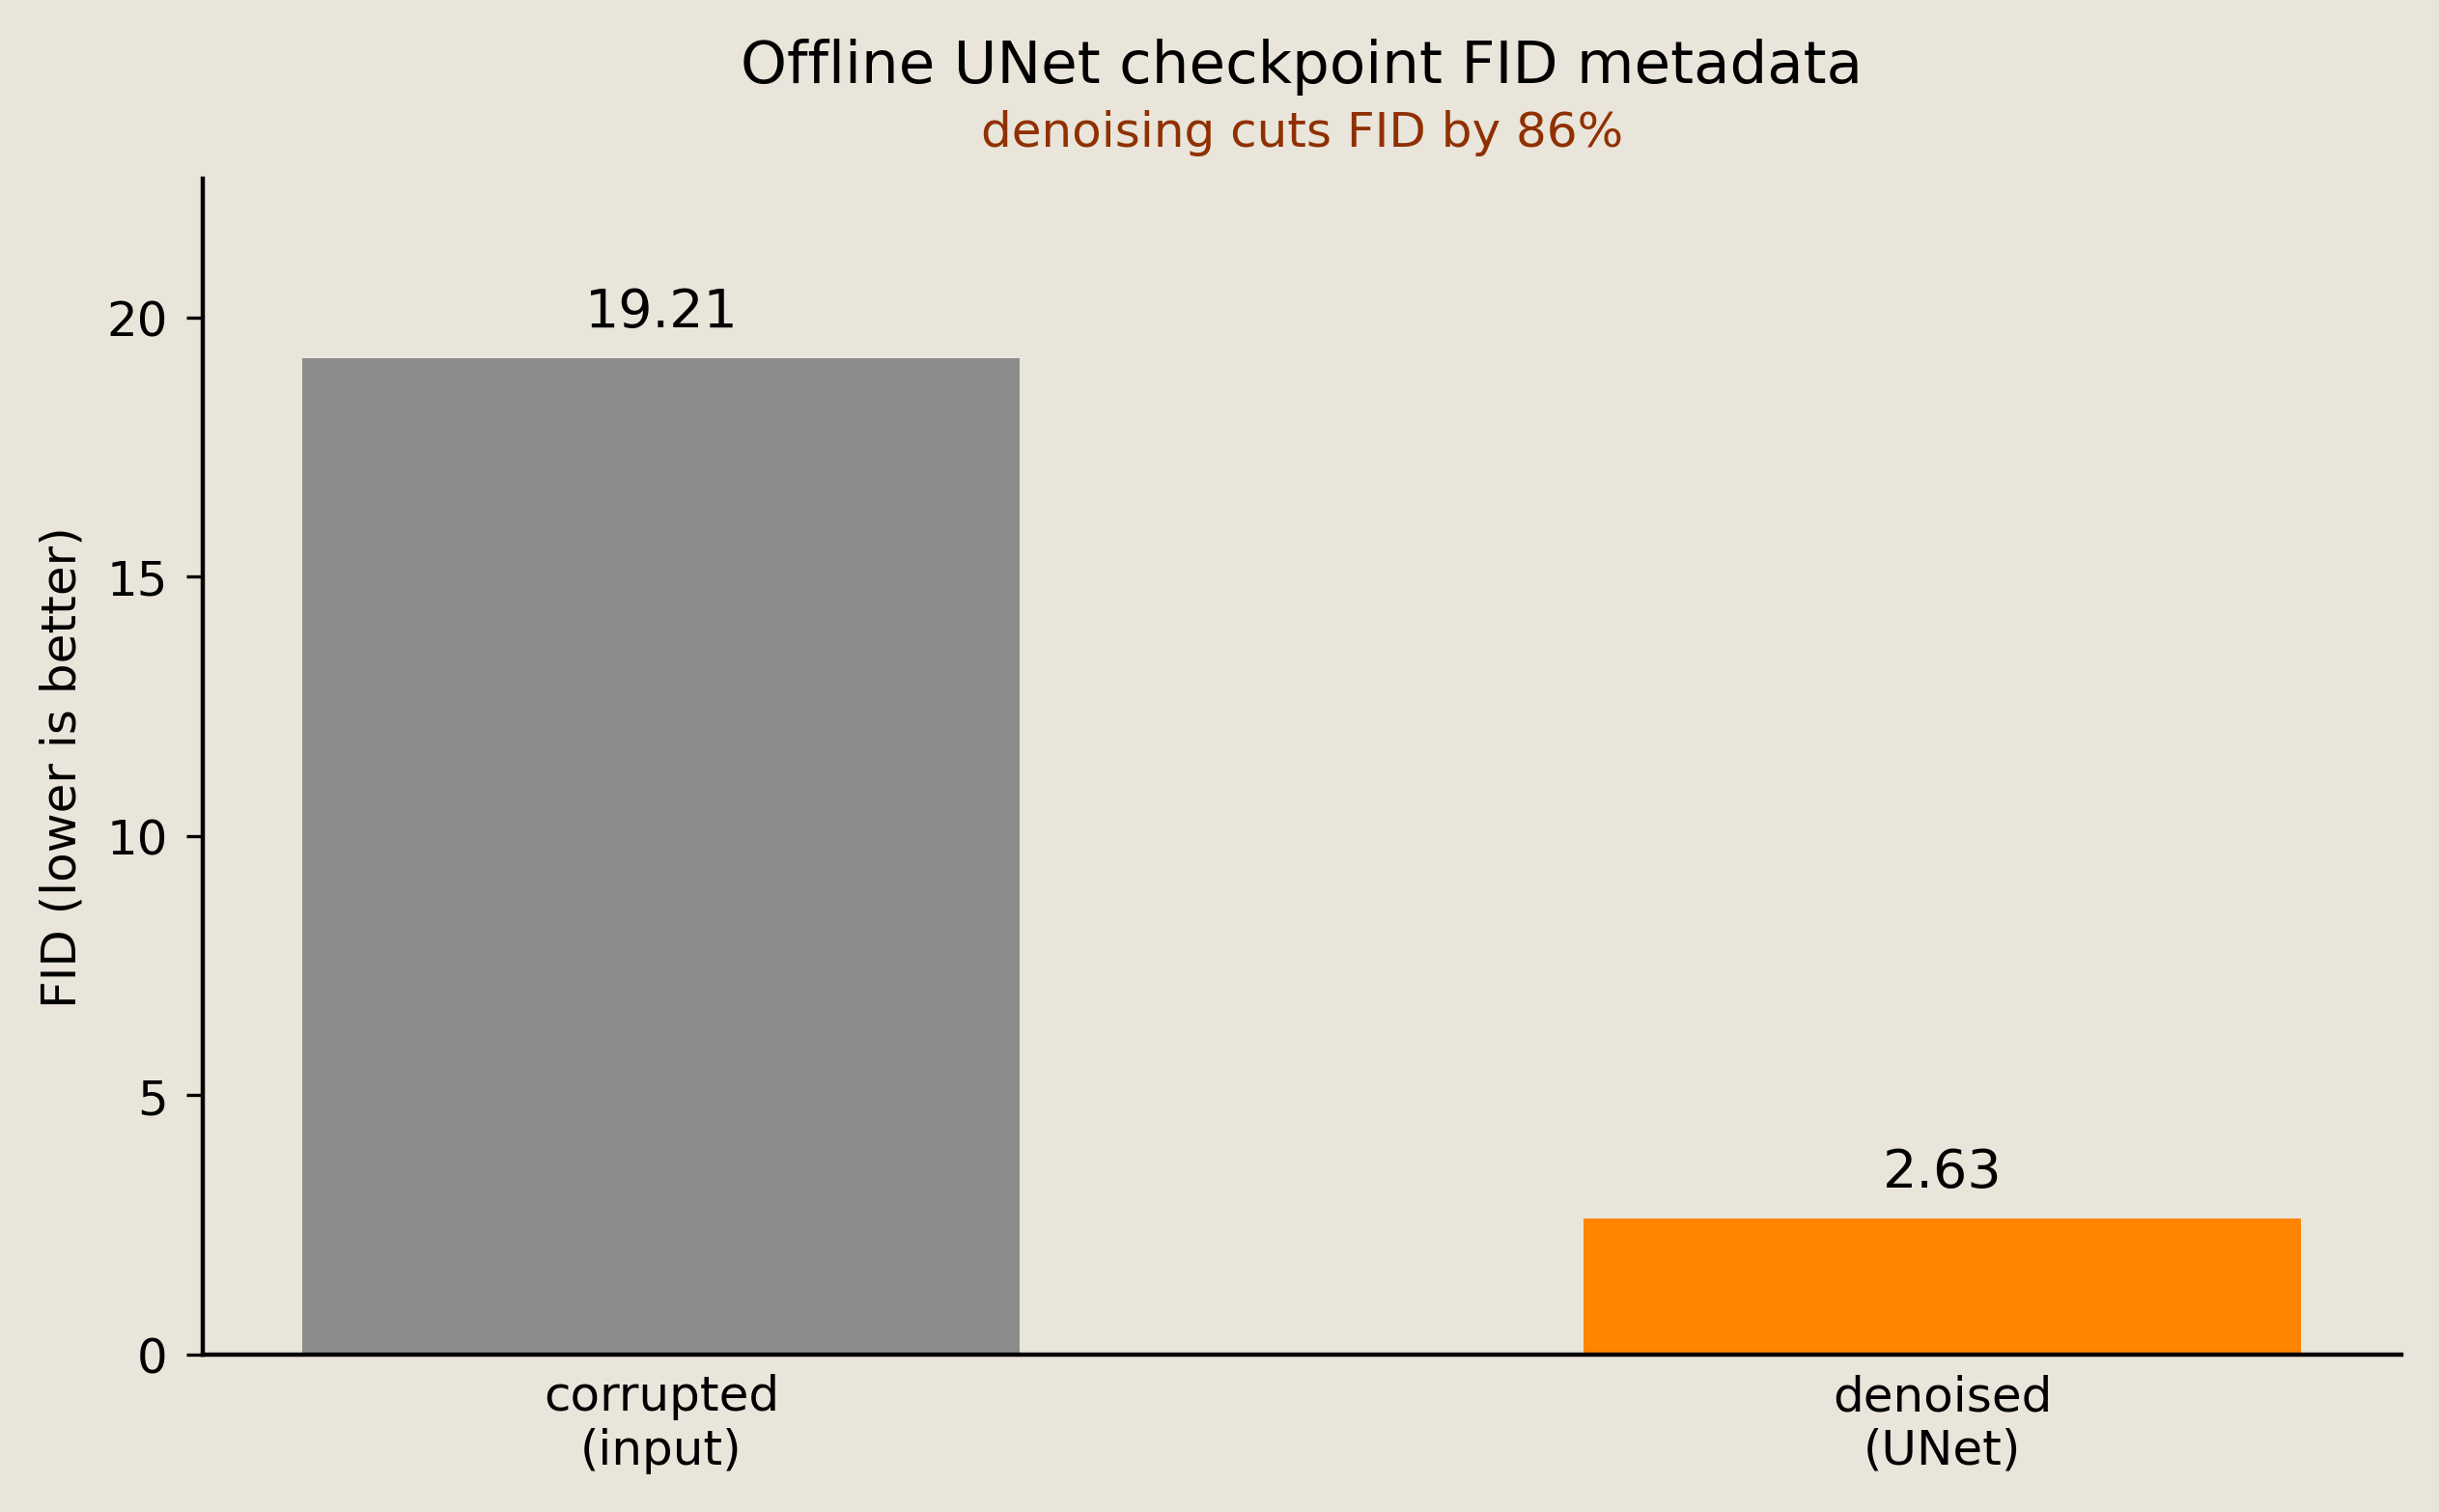

offline UNet metadata FID: corrupted 19.21 -> UNet-denoised 2.63
Torx outputs were not evaluated with FID.


In [20]:
fig = plot_fid_drop(
    fid_corrupted=meta["fid_corrupted"],
    fid_denoised=meta["fid_denoised"],
    title="Offline UNet checkpoint FID metadata",
)
savefig(fig, "07_discrete_diffusion_fid")
print(
    f"offline UNet metadata FID: corrupted {meta['fid_corrupted']:.2f} "
    f"-> UNet-denoised {meta['fid_denoised']:.2f}"
)
print("Torx outputs were not evaluated with FID.")

Inception features are trained on ImageNet-like RGB images, so their FID is a poor fit for binary MNIST. As a separate descriptive check, we fit 16 principal components to 32 clean reference images, then compare clean, corrupted, and denoised versions of the other 32 in that feature space. Keeping the reference and evaluation images separate avoids leakage; this score is not FID.


In [21]:
half = len(clean_all) // 2
pca_map = pca_features(clean_all[:half], n_components=16, seed=SEED)

pca_reference = pca_map(clean_all[:half])
pca_clean_eval = pca_map(clean_all[half:])
pca_corrupted_eval = pca_map(noisy_all[half:])
pca_denoised_eval = pca_map(denoised_all[half:])

fd_clean = frechet_distance(pca_reference, pca_clean_eval)
fd_corrupted = frechet_distance(pca_reference, pca_corrupted_eval)
fd_denoised = frechet_distance(pca_reference, pca_denoised_eval)

assert fd_denoised < fd_corrupted

print("Fréchet distance in PCA-16 space (32 reference, 32 evaluation)")
print(f"  clean evaluation     : {fd_clean:6.2f}")
print(f"  corrupted evaluation : {fd_corrupted:6.2f}")
print(f"  denoised evaluation  : {fd_denoised:6.2f}")

Fréchet distance in PCA-16 space (32 reference, 32 evaluation)
  clean evaluation     :  13.86
  corrupted evaluation :  29.64
  denoised evaluation  :  14.20


The offline UNet-denoised evaluation grids have lower PCA-space Fréchet distance than their corrupted counterparts. With only 32 reference and 32 evaluation images, this check is descriptive and is not FID.

## Conclusion

We ran posterior per-pixel denoising on binarized MNIST with Torx stochastic circuits.

- Each $28\times28$ image uses 784 `PNOT` gates, one per pixel.
- A host UNet supplies clean-pixel posterior probabilities, which the notebook maps to `PNOT` flip logits.
- One genuine Torx draw is shown separately from the thresholded 64-draw ensemble estimator.
- Bit-error values cover only the eight-image display batch.
- The committed FID values belong only to offline UNet artifacts. Torx outputs were not evaluated with FID.
- A leakage-free, equal-size PCA-space Fréchet check on committed grids is descriptive, not FID.

A natural next step is [`08_stochastic_convolutional_networks.ipynb`](08_stochastic_convolutional_networks.ipynb), which trains stochastic image circuits with parameter-shift gradients.

## References

1. <span id="ref-austin"></span>Austin, J., Johnson, D.D., Ho, J., Tarlow, D., van den Berg, R. 2021. [*Structured denoising diffusion models in discrete state-spaces*](https://arxiv.org/abs/2107.03006). NeurIPS 34.
2. <span id="ref-campbell"></span>Campbell, A., Benton, J., De Bortoli, V., Rainforth, T., Deligiannidis, G., Doucet, A. 2022. [*A continuous time framework for discrete denoising models*](https://arxiv.org/abs/2205.14987). NeurIPS 35.